In [1]:
!pip install sentence-transformers scikit-learn matplotlib seaborn


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentences = [
    "The bowler took three wickets in one over",
    "Cricket is a very popular sport in India",
    "The batsman scored a century in the match",

    "Cooking requires patience and creativity",
    "Adding spices enhances the flavor of food",
    "Baking a cake needs precise measurements",

    "Cybersecurity protects systems from attacks",
    "Strong passwords prevent unauthorized access",
    "Phishing attacks target user credentials",

    "Technology is changing the world rapidly"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)


In [5]:
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 1.0000004   0.41365498  0.56821954  0.06477355  0.07458308  0.08151497
   0.03629667  0.01265807  0.0064275   0.03242432]
 [ 0.41365498  1.          0.4339928   0.13693386  0.01166979  0.00672174
   0.07633822  0.00761464 -0.03876617  0.2924708 ]
 [ 0.56821954  0.4339928   0.9999999   0.03678441 -0.00758824  0.14873016
   0.01957571 -0.04017445  0.0202597   0.08240189]
 [ 0.06477355  0.13693386  0.03678441  1.0000001   0.37717327  0.2397933
  -0.0125603   0.03276834 -0.00745904  0.19368288]
 [ 0.07458308  0.01166979 -0.00758824  0.37717327  1.         -0.02457223
   0.04241571  0.08020037  0.11512504 -0.0317179 ]
 [ 0.08151497  0.00672174  0.14873016  0.2397933  -0.02457223  1.0000004
  -0.04449293 -0.06459562  0.11847067  0.00711256]
 [ 0.03629667  0.07633822  0.01957571 -0.0125603   0.04241571 -0.04449293
   0.99999994  0.33660278  0.39786053  0.10551697]
 [ 0.01265807  0.00761464 -0.04017445  0.03276834  0.08020037 -0.06459562
   0.33660278  1.0000002   0.45082146 -0.02235165]
 [

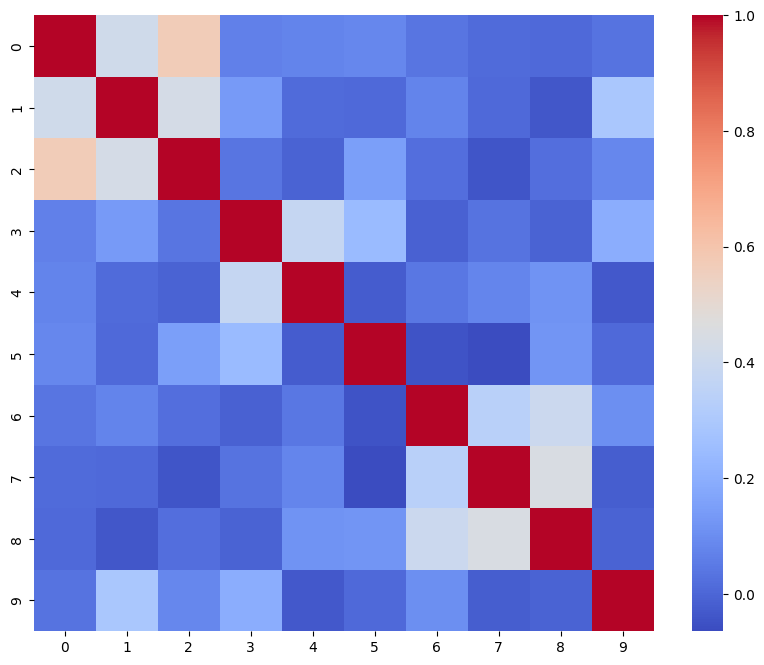

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, cmap='coolwarm')
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-3:][::-1]

for idx in top_indices:
    print(sentences[idx], similarities[idx])

The bowler took three wickets in one over 1.0000001
The batsman scored a century in the match 0.56821966
Cricket is a very popular sport in India 0.41365492
